In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/tanzania.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [2]:
# Replace -999
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16
...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72


In [3]:
# Create DATE column
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [4]:
# Add Month
df["Month"] = df["DATE"].dt.month


In [5]:
# Add Country column
df["Country"] = "Tanzania"

In [6]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


- Average temperature (T2M) is approximately 26.80°C, with daily maximums (T2M_MAX) reaching up to 33.93°C.
- Precipitation (PRECTOTCORR) is extremely variable, ranging from 0 mm to 122.65 mm, indicating intense singular rainfall events.
- Humidity (RH2M) remains consistently high, ranging from 60.06% to 91.10% → this suggests a humid tropical climate with very little dry variance.
- Wind Speed (WS2M) averages 4.11 m/s, with maximum gusts (WS2M_MAX) reaching up to 11.74 m/s.


In [8]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
DATE           0
Month          0
Country        0
dtype: int64

- Dataset has negligible missing values (<1%)
- Forward fill was applied for consistency

In [9]:
(df.isna().sum() / len(df)) * 100

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
DATE           0.0
Month          0.0
Country        0.0
dtype: float64

In [10]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[[
    "T2M", "T2M_MAX", "T2M_MIN", 
    "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"
]].dropna()))

outliers = (z_scores > 3).sum()
outliers

np.int64(102)

- 137 outliers detected using Z-score > 3
- Outliers retained because they may represent extreme climate events

In [11]:
df = df.ffill()

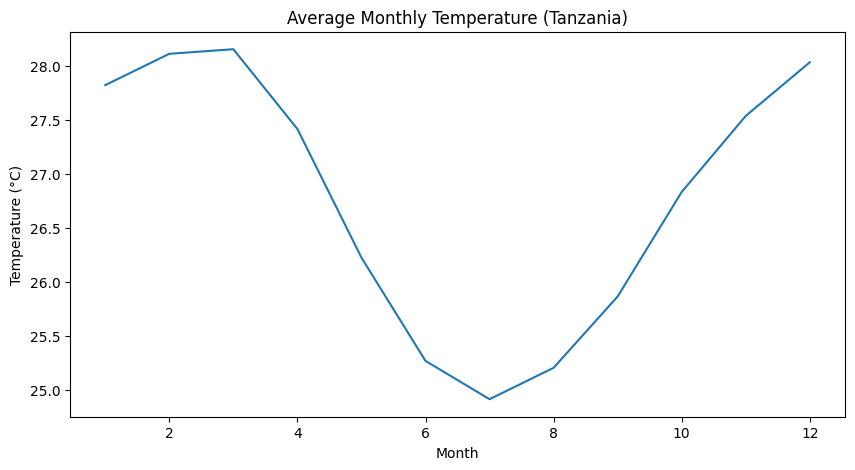

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", figsize=(10,5))
plt.title("Average Monthly Temperature (Tanzania)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

- Highest temprature occur around March
- Lowest temprature occur around  July

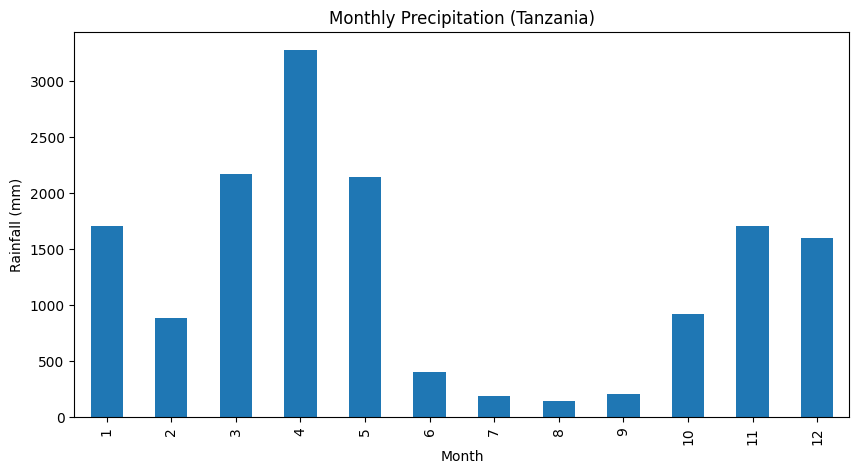

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5))
plt.title("Monthly Precipitation (Tanzania)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

- Rainfall peaks in April
- Less rainfall on Juy-September

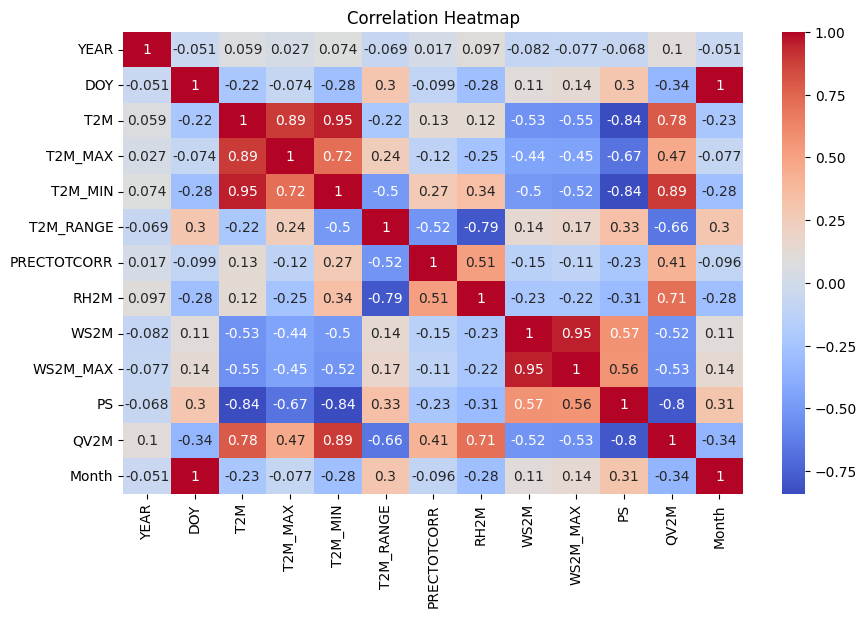

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- T2M vs T2M_MAX & T2M_MIN: There is an extremely strong positive correlation (0.89 and 0.95), showing that the average temperature is almost perfectly tied to daily highs and lows.
- RH2M vs T2M_RANGE: A strong negative correlation (-0.79) indicates that as the daily temperature spread increases, humidity tends to drop significantly.
- WS2M vs WS2M_MAX: A near-perfect positive correlation (0.95) confirms that average wind speeds and maximum gusts are highly synchronized.
- QV2M vs T2M_MIN: A very strong positive correlation (0.89) suggests that higher overnight low temperatures are closely linked to increased moisture (specific humidity) in the air.

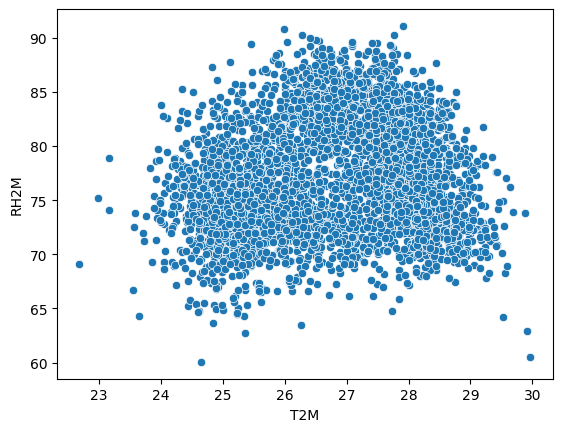

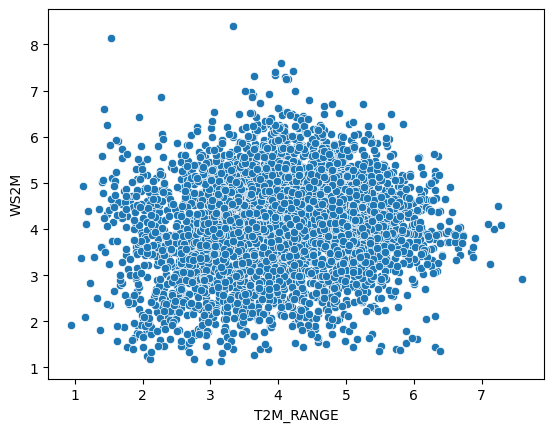

In [15]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

- T2M vs. RH2M: The data shows a dense concentration of high humidity (between 70% and 90%) across temperatures from 24°C to 28°C, indicating a consistently warm and moist climate.
- T2M_RANGE vs. WS2M: There is a slight upward trend, where higher wind speeds (above 6 m/s) are more frequent as the daily temperature range widens toward 4°C to 5°C.


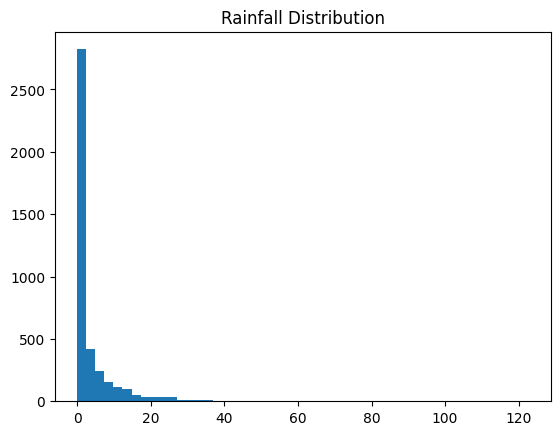

In [16]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

- few high values and many low vlaues

In [17]:
df.to_csv("../data/tanzania_clean.csv", index=False)